In [ ]:
from utils.models import CNNLSTM
from utils.preprocessing import FEATURES, normalize_label_name, preprocess_data
from utils.evaluation import (
    evaluate_model,
    load_and_evaluate_rf_model,
    load_and_evaluate_cnnlstm_model,
)
import torch
import torch.nn as nn
import joblib
import pandas as pd
import numpy as np

## Preprocess data

In [ ]:
df_cicids2017 = preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [57]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (497759, 7)
CICIoT test shape: (1850844, 7)


## Load Models

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21724\2191884484.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Evaluation for CICIDS2017-trained model tested on CICIoT2023:

=== CICIDS2017-trained model tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1849    1.0000    0.3121    342255
DOS_HTTP_FLOOD     1.0000    0.0000    0.0001   1508589

      accuracy                         0.1849   1850844
     macro avg     0.5925    0.5000    0.1561   1850844
  weighted avg     0.8493    0.1849    0.0578   1850844


=== Per-Label Accuracy ===

BENIGN: 1.0000
DOS_HTTP_FLOOD: 0.0000


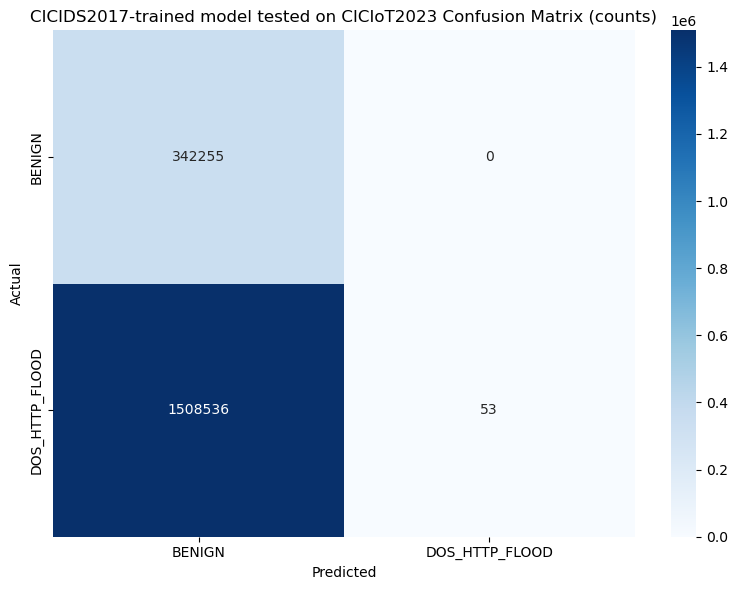

In [ ]:
load_and_evaluate_rf_model(
    "models/random_forest_wednesday_labeled.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained model tested on CICIoT2023"
)

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21724\2191884484.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Evaluation for CICIoT2023-trained model tested on CICIDS2017:

=== CICIoT2023-trained model tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8396    0.8829    0.8608    342990
DOS_HTTP_FLOOD     0.7071    0.6263    0.6643    154769

      accuracy                         0.8031    497759
     macro avg     0.7734    0.7546    0.7625    497759
  weighted avg     0.7984    0.8031    0.7997    497759


=== Per-Label Accuracy ===

BENIGN: 0.8829
DOS_HTTP_FLOOD: 0.6263


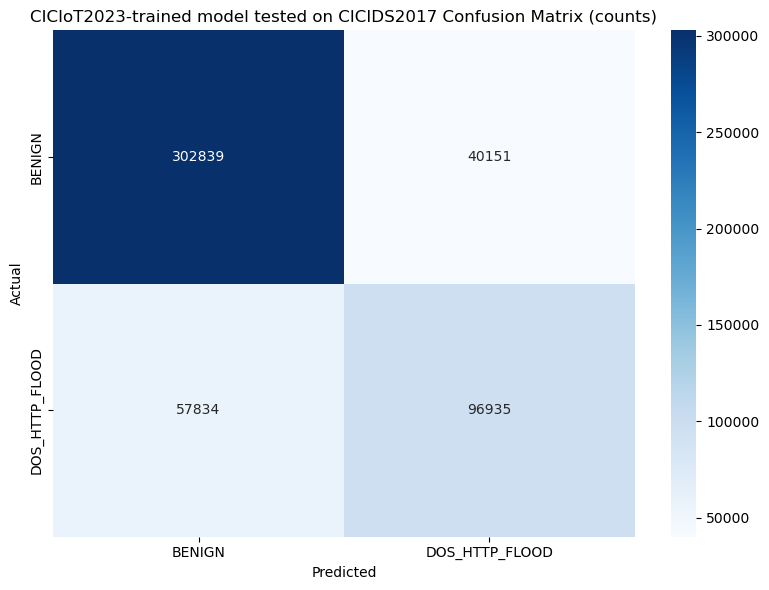

In [ ]:
load_and_evaluate_rf_model(
    "models/random_forest_ciciot2023_labeled_conn.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained model tested on CICIDS2017"
)

c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(


Evaluation for CICIoT2023-trained model tested on CICIDS2017:

=== CICIoT2023-trained model tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.6814    0.9195    0.7827    342990
DOS_HTTP_FLOOD     0.2090    0.0472    0.0770    154769

      accuracy                         0.6482    497759
     macro avg     0.4452    0.4833    0.4298    497759
  weighted avg     0.5345    0.6482    0.5633    497759


=== Per-Label Accuracy ===

BENIGN: 0.9195
DOS_HTTP_FLOOD: 0.0472


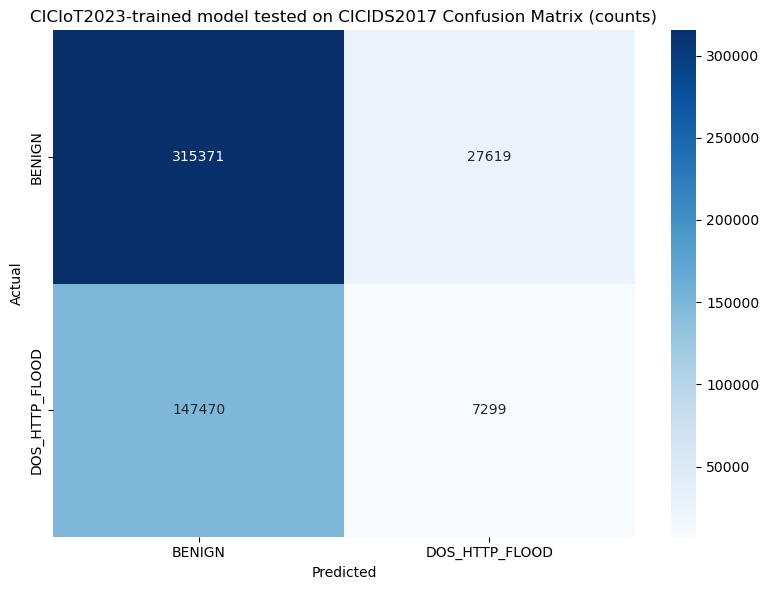

In [ ]:
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_ciciot2023_labeled_conn.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained model tested on CICIDS2017"
)

c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\torch\nn\modules\rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.lstm(


Evaluation for CICIDS2017-trained model tested on CICIoT2023:

=== CICIDS2017-trained model tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1850    0.9996    0.3122    342255
DOS_HTTP_FLOOD     0.9240    0.0010    0.0021   1508589

      accuracy                         0.1857   1850844
     macro avg     0.5545    0.5003    0.1572   1850844
  weighted avg     0.7874    0.1857    0.0594   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9996
DOS_HTTP_FLOOD: 0.0010


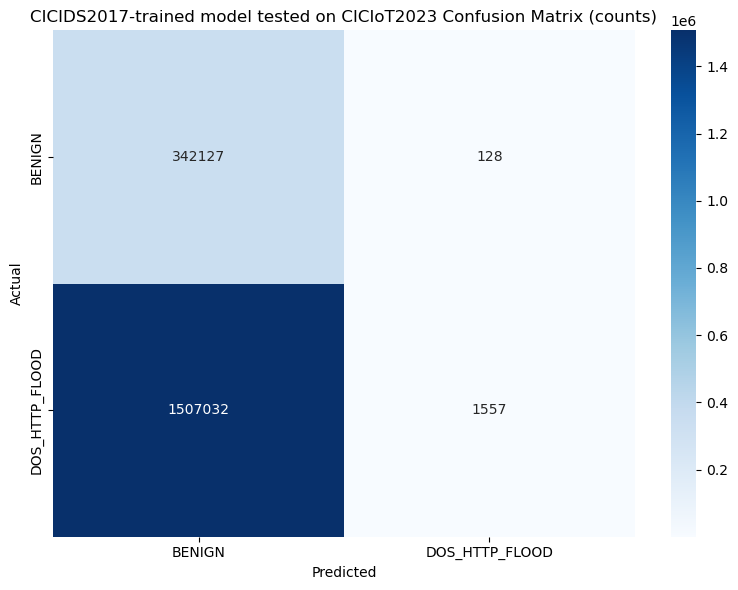

In [81]:
load_and_evaluate_cnnlstm_model(
    "models/cnnlstm_wednesday_labeled.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained model tested on CICIoT2023"
)